# Same-strand overlaps: all ordered pairs, all overlap lengths

Loads `20260810_strand_scan_same_full.csv`, written by `20260810_same_strand_all.py`.

**Pairs are ordered.** The overlap couples the upstream gene's C-terminus to the
downstream gene's N-terminus, so "A upstream of B" and "B upstream of A" are
different constructs of different residues. In the csv `pf1` is always the
**upstream** gene and `pf2` the **downstream** one; they are renamed below.

**Two frames, no third.**

| frame | overlap % 3 | upstream wobble lands on | downstream wobble lands on |
|---|---|---|---|
| **+2** (named "A" in data) | 1 | downstream 1st | upstream 2nd |
| **+1** (named "B" in data) | 2 | downstream 2nd | upstream 1st |

In [5]:
import importlib.util
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import palettable
import pandas as pd
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                            'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

colorTable = {}
colorTable['k'] = [0, 0, 0]
colorTable['g'] = [27/255, 158/255, 119/255]
colorTable['o'] = [217/255, 95/255, 2/255]

# FAMILY_LENGTHS comes from the scan module so there is one source of truth
HERE = os.getcwd()   # Jupyter runs with cwd set to the notebook folder
sys.path.insert(0, HERE)
spec = importlib.util.spec_from_file_location(
    "strand_scan", os.path.join(HERE, "20260821_strand_scan.py"))
SCAN = importlib.util.module_from_spec(spec)
sys.modules["strand_scan"] = SCAN
spec.loader.exec_module(SCAN)
LENGTHS = SCAN.FAMILY_LENGTHS

CSV = "20260821_strand_scan_same_full.csv"
SMOOTH = 20    # step 1, so 7 points spans ~21 nt within a frame


In [6]:
df = pd.read_csv(CSV)
assert (df.overlap_nuc % 3 != 0).all(), "frame 0 cannot exist for same strand"

df["frame"] = np.where(df.overlap_nuc % 3 == 1, "A", "B")
df["better"] = df.zscore_dist < 0
df = df.rename(columns={"pf1": "upstream", "pf2": "downstream"})

n_pairs = df.groupby(["upstream", "downstream"]).ngroups
print(f"{len(df)} runs, {n_pairs} ordered pairs, "
      f"overlaps {df.overlap_nuc.min()}-{df.overlap_nuc.max()} nt")
print(df.frame.value_counts().to_dict())

# infer the overlap step from the data rather than assuming step 1
ovs = np.sort(df.overlap_nuc.unique())
STEP = int(np.gcd.reduce(np.diff(ovs))) if len(ovs) > 1 else 1
expected = len(SCAN.enumerate_tasks(sorted(LENGTHS), STEP, "same"))
print(f"overlap step {STEP}; {expected} tasks expected")
if len(df) < expected:
    print(f"WARNING: {expected - len(df)} of {expected} tasks missing -- tasks run "
          f"in pair order, so a partial csv is a biased sample of pairs.")

28608 runs, 272 ordered pairs, overlaps 13-323 nt
{'A': 14304, 'B': 14304}
overlap step 1; 28608 tasks expected


## 1. Overlap fractions

Fraction of ordered pairs whose overlap beats natural-sequence energies, against
overlap length. First pooled over both frames, then split.

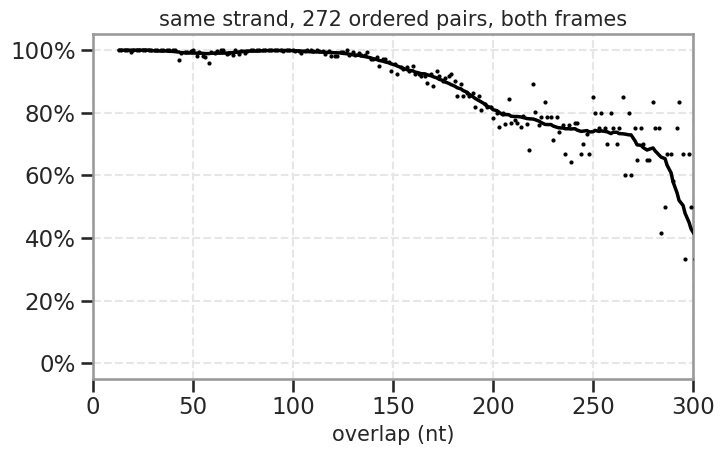

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.8))

g = df.groupby("overlap_nuc")["better"].mean().sort_index()
ax.plot(g.index, g.values, "o", color=colorTable['k'], ms=2, zorder=3)
ax.plot(g.index, g.rolling(SMOOTH, min_periods=1, center=True).mean().values,
        "-", color=colorTable['k'], lw=2.5, zorder=4)

ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_yticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.01, 0.2)])
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 300)
ax.set_xlabel("overlap (nt)")
# ax.set_ylabel("pairs beating natural energies")
ax.set_title(f"same strand, {n_pairs} ordered pairs, both frames")
plt.tight_layout()
# plt.savefig("20260810_same_strand_overlap_fractions_all.svg", bbox_inches="tight")

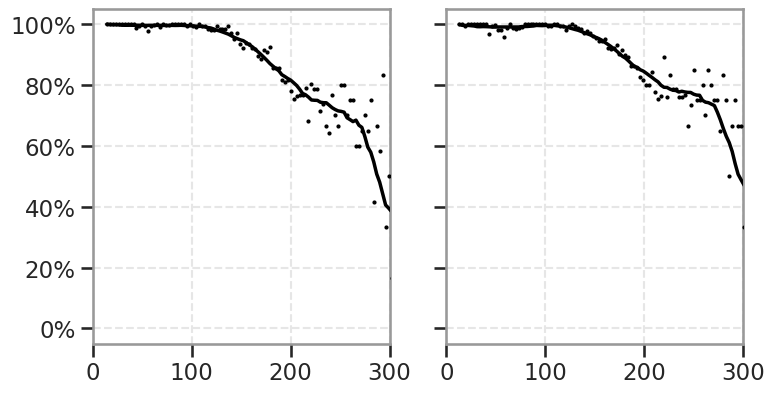

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4.2), sharey=True)
titles = {"A": "frame +2:  up wobble $\\to$ dn 1st",
          "B": "frame +1:  up wobble $\\to$ dn 2nd"}

for (frame, colour), ax in zip((("B", 'g'), ("A", 'o')), axes):
    sub = df[df.frame == frame]
    g = sub.groupby("overlap_nuc")["better"].mean().sort_index()
    ax.plot(g.index, g.values, "o", color="k", ms=2, zorder=3)
    ax.plot(g.index, g.rolling(SMOOTH, min_periods=1, center=True).mean().values,
            "-", color="k", lw=2.5, zorder=4)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.set_yticklabels([f"{int(x*100)}%" for x in np.arange(0, 1.01, 0.2)])
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(0, 300)
    # ax.set_xlabel("overlap (nt)")
    # ax.set_title(titles[frame])

# axes[0].set_ylabel("pairs beating natural energies")
plt.tight_layout()
plt.savefig("Panels/20260810_same_strand_overlap_fractions_by_frame.svg", bbox_inches="tight")

## 2. Max-overlap matrices

The longest overlap that still beats natural energies, per pair, in two flavours.

- **absolute** — that overlap in nt. Confounded by gene length: two long families
  can post a long overlap simply because there is more gene to consume.
- **normalised** — the same divided by `maxpair = 3 * min(L1, L2)`, the shorter
  gene's coding length, so it reads as *what fraction of the shorter gene can be
  overlapped*. Puts PF00096 (23 aa) and PF00009 (162 aa) on one scale.

In [9]:
max_success = (df[df.better]
               .groupby(["upstream", "downstream", "frame"])["overlap_nuc"].max()
               .reset_index()
               .rename(columns={"overlap_nuc": "max_success_overlap"}))

max_success["maxpair"] = [3 * min(LENGTHS[u], LENGTHS[d])
                          for u, d in zip(max_success.upstream, max_success.downstream)]
max_success["norm_success"] = max_success.max_success_overlap / max_success.maxpair

# one shared family order for all four panels, weakest first
score = pd.concat([max_success.groupby("upstream").max_success_overlap.mean(),
                   max_success.groupby("downstream").max_success_overlap.mean()],
                  axis=1).mean(axis=1)
order = score.reindex(sorted(LENGTHS), fill_value=0).sort_values().index.tolist()

print(f"{len(max_success)} (ordered pair, frame) combinations with >=1 success, "
      f"out of {n_pairs * 2} possible")
max_success.head()

544 (ordered pair, frame) combinations with >=1 success, out of 544 possible


,upstream,downstream,frame,max_success_overlap,maxpair,norm_success
0,PF00004,PF00009,A,199,330,0.603030
1,PF00004,PF00009,B,197,330,0.596970
2,PF00004,PF00011,A,238,246,0.967480
3,PF00004,PF00011,B,224,246,0.910569
4,PF00004,PF00013,A,166,174,0.954023


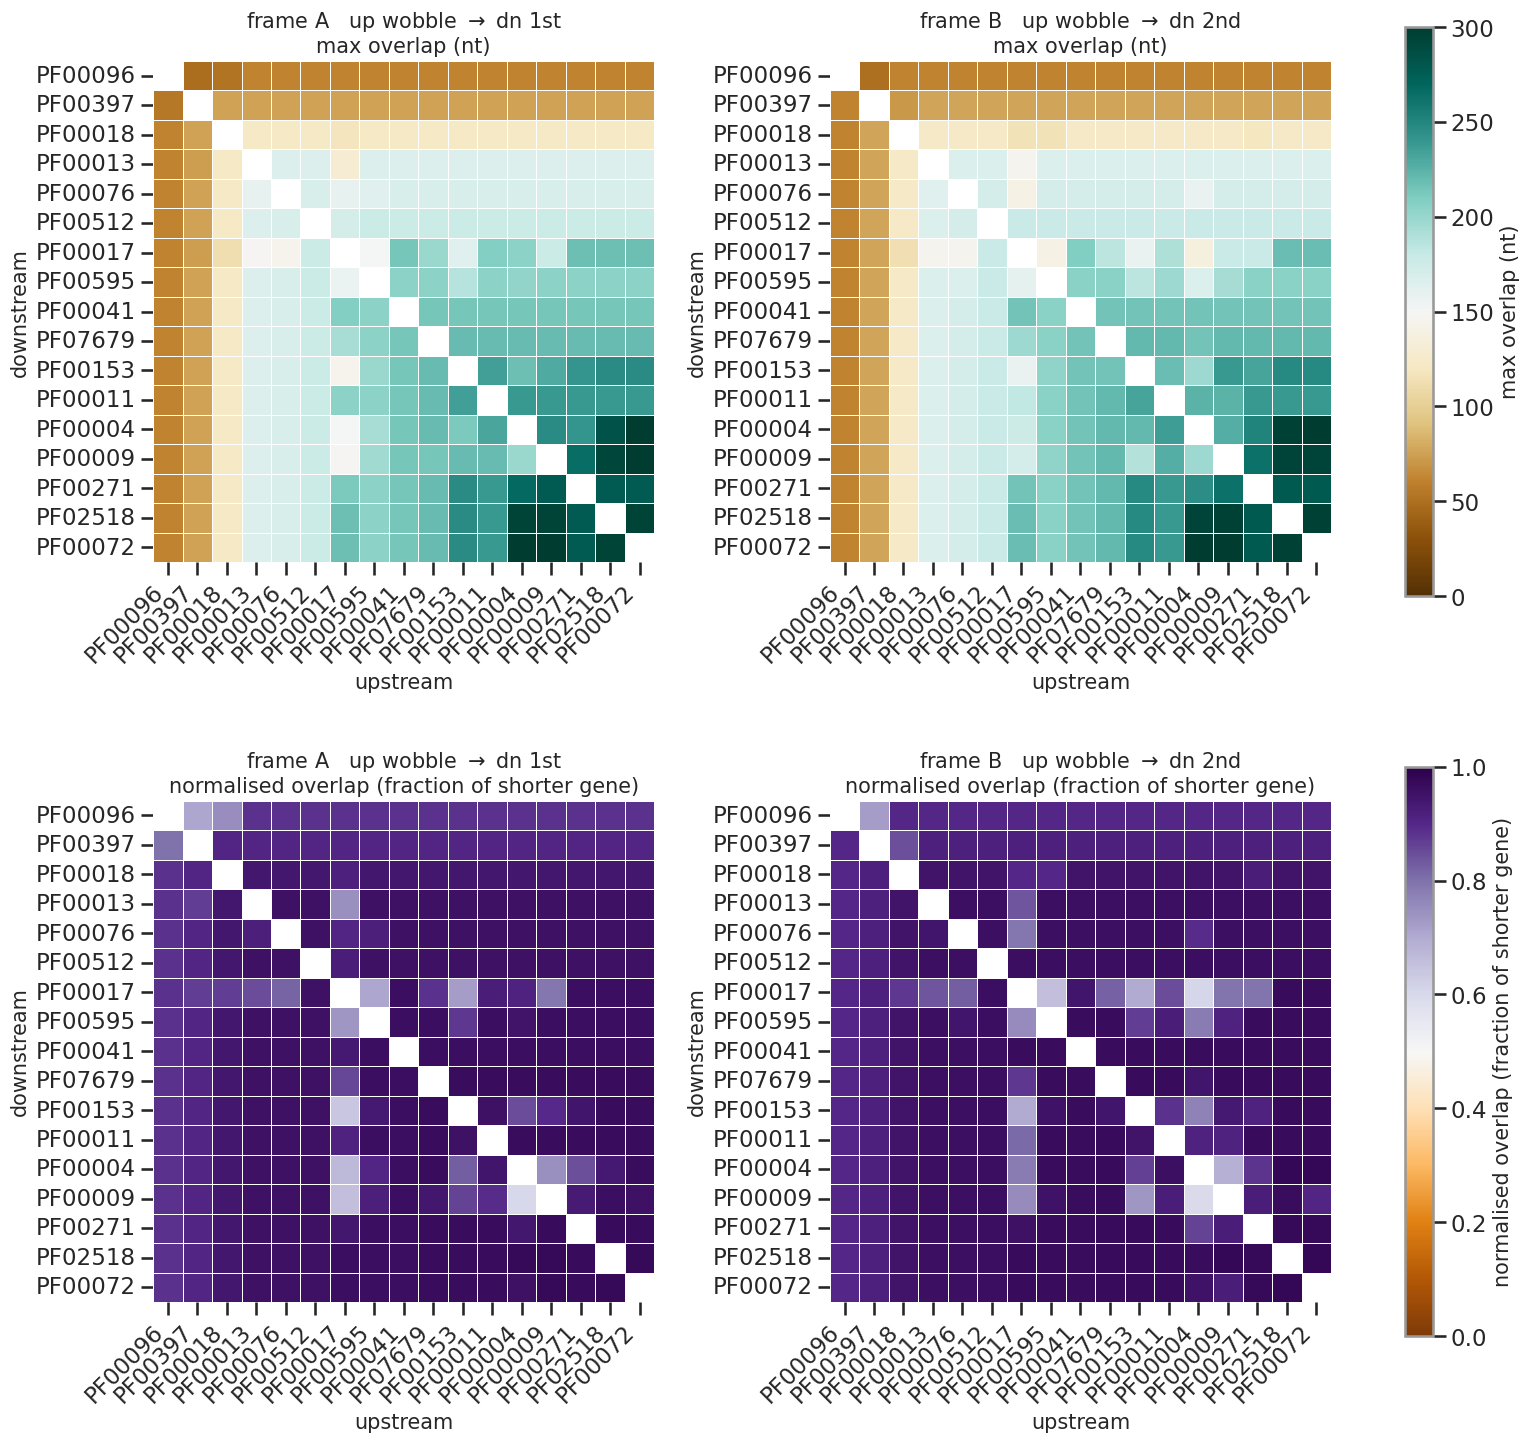

In [10]:
# rows = quantity, columns = frame.  x = upstream and y = downstream throughout,
# so each matrix already carries both orderings.
QUANTITIES = [
    ("max_success_overlap",
     palettable.colorbrewer.diverging.BrBG_11.mpl_colormap,
     TwoSlopeNorm(vmin=0, vcenter=150, vmax=300),
     "max overlap (nt)"),
    ("norm_success",
     palettable.colorbrewer.diverging.PuOr_11.mpl_colormap,
     plt.Normalize(0, 1),
     "normalised overlap (fraction of shorter gene)"),
]
FRAME_TITLES = {"A": "frame A   up wobble $\\to$ dn 1st",
                "B": "frame B   up wobble $\\to$ dn 2nd"}

fig, axes = plt.subplots(2, 2, figsize=(19, 17),
                         gridspec_kw={"wspace": 0.35, "hspace": 0.30})

for row, (value, cmap, norm, label) in enumerate(QUANTITIES):
    for col, frame in enumerate(["A", "B"]):
        ax = axes[row][col]
        sub = max_success[max_success.frame == frame]
        piv = (sub.pivot(index="downstream", columns="upstream", values=value)
                  .reindex(index=order, columns=order))

        sns.heatmap(piv, ax=ax, cmap=cmap, norm=norm, linewidths=0.5, square=True,
                    cbar=False, xticklabels=True, yticklabels=True)
        ax.grid(False)
        ax.set_title(f"{FRAME_TITLES[frame]}\n{label}")
        ax.set_xlabel("upstream")
        ax.set_ylabel("downstream")
        ax.tick_params(axis="x", rotation=45)
        ax.set_xticklabels(ax.get_xticklabels(), ha="right", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=list(axes[row]),
                 label=label)

# plt.savefig("20260810_same_strand_max_overlap_heatmap.svg", bbox_inches="tight")

## 3. Orientation asymmetry — which gene should go first?

Every pair appears twice in the scan, once each way round, and the two are
different constructs: the overlap always couples the **upstream** gene's
C-terminus to the **downstream** gene's N-terminus, so swapping the order swaps
which residues have to absorb the constraint. The question here is whether some
pairs have a preferred order — one that is easier *systematically*, across the
whole overlap grid, not at a single length.

The statistic is `zscore_dist`, not the max overlap of section 2. With 95% of
runs already beating natural energies the max-overlap matrices are saturated and
read the same in both directions for three quarters of pairs; the distance to the
Pareto front still moves. Lower `zscore_dist` is better, so a **negative** `dz`
means the first-named ordering wins.

Monte-Carlo noise on a single run is ~0.32 z, so no individual overlap length is
evidence of anything. Pairing the two orderings at matched overlap length and
frame cancels everything the pair has in common and leaves the ordering effect,
which is then read as a trend over the 17–104 overlaps each pair provides.

### 3.1 Which pairs have a preferred order?

A Wilcoxon signed-rank test per unordered pair, Benjamini–Hochberg corrected
across the 136 pairs. `consistency` is the fraction of overlap lengths at which
the winning order actually wins — the plain-sight version of the p-value.

In [11]:
# Pair the two orientations of every unordered pair.  Both orientations are
# scanned on the same overlap grid (12 .. 3*min(L1,L2)-6), so every run has an
# exact partner: same pair, same overlap length, same frame, genes swapped.
from scipy import stats
from statsmodels.stats.multitest import multipletests

d = df.copy()
d["lo"] = np.minimum(d.upstream, d.downstream)
d["hi"] = np.maximum(d.upstream, d.downstream)
d["dirn"] = np.where(d.upstream == d.lo, "lo_up", "hi_up")

paired = (d.pivot_table(index=["lo", "hi", "overlap_nuc", "frame"],
                        columns="dirn", values="zscore_dist")
           .reset_index()
           .dropna(subset=["lo_up", "hi_up"]))

# zscore_dist is negative when the overlap beats natural energies, so a NEGATIVE
# dz means the lo-upstream orientation is the easier one.
paired["dz"] = paired.lo_up - paired.hi_up

print(f"{len(paired)} matched orientation pairs over "
      f"{paired.groupby(['lo', 'hi']).ngroups} unordered pairs "
      f"({paired.groupby(['lo', 'hi']).size().min()}-"
      f"{paired.groupby(['lo', 'hi']).size().max()} overlaps each)")
print(f"per-run dz sd {paired.dz.std():.2f}, consistent with two independent "
      f"draws at the MC sd of ~0.32 -- single overlaps say nothing, only the "
      f"trend across overlaps does")

14304 matched orientation pairs over 136 unordered pairs (34-208 overlaps each)
per-run dz sd 0.48, consistent with two independent draws at the MC sd of ~0.32 -- single overlaps say nothing, only the trend across overlaps does


In [12]:
# One test per unordered pair: is dz consistently signed across overlap lengths?
rows = []
for (lo, hi), g in paired.groupby(["lo", "hi"]):
    dz = g.dz.values
    rows.append(dict(lo=lo, hi=hi, n=len(dz), mean_dz=dz.mean(),
                     sem_dz=dz.std(ddof=1) / np.sqrt(len(dz)),
                     frac_lo_up_better=(dz < 0).mean(),
                     p=stats.wilcoxon(dz).pvalue))

asym = pd.DataFrame(rows)
asym["q"] = multipletests(asym.p, method="fdr_bh")[1]

# state it as a direction rather than a sign
asym["upstream_gene"] = np.where(asym.mean_dz < 0, asym.lo, asym.hi)
asym["downstream_gene"] = np.where(asym.mean_dz < 0, asym.hi, asym.lo)
asym["effect"] = asym.mean_dz.abs()          # z units the winning order gains
asym["consistency"] = np.where(asym.mean_dz < 0, asym.frac_lo_up_better,
                               1 - asym.frac_lo_up_better)

# lag-1 autocorrelation along the overlap axis, to check the runs within a pair
# are not so smooth that the signed-rank test is counting the same fact twice
ac = [np.corrcoef(v[:-1], v[1:])[0, 1] for _, g in paired.groupby(["lo", "hi", "frame"])
      for v in [g.sort_values("overlap_nuc").dz.values] if len(v) > 8 and v.std() > 0]
print(f"lag-1 autocorrelation of dz within a pair: median {np.nanmedian(ac):+.2f} "
      f"-- neighbouring overlaps are near-independent")

sig = asym[asym.q < 0.05].sort_values("effect", ascending=False)
print(f"\n{len(sig)} of {len(asym)} pairs have a directional preference at q < 0.05\n")
print(sig[["upstream_gene", "downstream_gene", "n", "effect",
           "consistency", "q"]].head(20).to_string(index=False))

lag-1 autocorrelation of dz within a pair: median +0.10 -- neighbouring overlaps are near-independent

82 of 136 pairs have a directional preference at q < 0.05

upstream_gene downstream_gene   n   effect  consistency            q
      PF00397         PF00271  44 0.920302     0.977273 5.820766e-10
      PF00096         PF00271  34 0.917062     0.970588 1.055499e-08
      PF00096         PF00041  34 0.686980     0.823529 1.866650e-04
      PF00096         PF00018  34 0.686010     0.852941 2.178814e-05
      PF00096         PF07679  34 0.668169     0.794118 1.996295e-05
      PF00017         PF00271 138 0.583401     0.913043 5.559585e-20
      PF00096         PF02518  34 0.570712     0.823529 9.830846e-04
      PF00018         PF00271  74 0.540340     0.837838 7.015582e-10
      PF00013         PF00271 104 0.528035     0.942308 9.400458e-16
      PF00595         PF00271 130 0.520638     0.930769 5.559585e-20
      PF00076         PF00271 106 0.501235     0.952830 9.454922e-17
      PF00

### 3.2 The asymmetries are one per-family effect, not 136 pair-specific ones

Scoring each family by its mean advantage over all 16 partners recovers 86% of
the pair-level variance: a pair's preferred order is almost entirely predictable
from the two families' individual preferences for sitting upstream. Four families
are significantly easier upstream (**PF00096**, PF00397, PF00009, PF00512) and two
significantly easier downstream (**PF00271** most strongly, then PF00041). Gene
length does not explain it (r = −0.34, and the two extremes PF00096 at 23 aa and
PF00271 at 95 aa are not the length extremes).

In [13]:
# The pair-level asymmetries are not independent: they mostly reduce to a single
# per-family preference for sitting upstream or downstream.  Score each family by
# its mean advantage over all 16 partners, positive = easier upstream.
signed = pd.concat([asym.assign(fam=asym.lo, adv=-asym.mean_dz),
                    asym.assign(fam=asym.hi, adv=asym.mean_dz)])

fam = signed.groupby("fam").adv.agg(["mean", "sem", "count"])
fam["t"] = fam["mean"] / fam["sem"]
fam["p"] = 2 * stats.t.sf(fam.t.abs(), fam["count"] - 1)
fam["q"] = multipletests(fam.p, method="fdr_bh")[1]
fam["len_aa"] = [LENGTHS[f] for f in fam.index]
fam = fam.sort_values("mean", ascending=False)

print("upstream advantage per family (z units, + = easier upstream)\n")
print(fam[["mean", "sem", "q", "len_aa"]].to_string())

# how much of the pair asymmetry is just the two families' scores?
u = fam["mean"].to_dict()
asym["pred"] = [u[b] - u[a] for a, b in zip(asym.lo, asym.hi)]   # predicted mean_dz
r = np.corrcoef(asym.mean_dz, asym.pred)[0, 1]
asym["resid"] = asym.mean_dz - asym.pred
print(f"\nadditive family model explains R2 = {r**2:.2f} of the pair asymmetry; "
      f"residual sd {asym.resid.std():.2f} vs raw sd {asym.mean_dz.std():.2f}")
print(f"upstream advantage vs gene length: r = "
      f"{np.corrcoef(fam['mean'], fam.len_aa)[0, 1]:+.2f}")

upstream advantage per family (z units, + = easier upstream)

             mean       sem         q  len_aa
fam                                          
PF00096  0.399751  0.059183  0.000055      23
PF00397  0.216781  0.062851  0.010138      28
PF00009  0.201919  0.031864  0.000076     162
PF00512  0.156997  0.042063  0.006806      62
PF00011  0.026456  0.039398  0.725484      82
PF00595  0.011894  0.047049  0.911039      71
PF00013  0.007949  0.051571  0.934536      58
PF00017  0.002280  0.050296  0.964448      75
PF00004 -0.022495  0.027549  0.659844     110
PF00018 -0.023157  0.071496  0.911039      43
PF00076 -0.027500  0.046235  0.733420      59
PF02518 -0.060192  0.046334  0.363001     101
PF00153 -0.079489  0.042170  0.149144      85
PF00072 -0.082787  0.033021  0.058690     108
PF07679 -0.109682  0.058098  0.149144      76
PF00041 -0.169417  0.042220  0.004801      74
PF00271 -0.449307  0.061776  0.000046      95

additive family model explains R2 = 0.87 of the pair asymmetry;

### 3.3 Is it really about ordering?

Two checks. Frames A and B are independent samples of the same pair, so their
asymmetries should agree — and they are the control for a codon-pairing artefact:
(X upstream, frame A) carries the same codon pairing as (Y upstream, frame B), so
an effect that were only about which codon position meets which would **flip sign**
between frames and give a negative correlation here. It gives +0.54.

Section 4 makes this exact: `dz_A = T + P` and `dz_B = T - P`, so r = +0.54 is
the statement that the ordering contrast carries (1+r)/(1-r) = 3.4 times the
variance of the pairing one. What it does **not** establish is *why* one
ordering is easier. Section 4 tests the obvious explanation and rejects it.

In [14]:
# Robustness: frame A and frame B are two independent looks at the same pair.
# They are also the control for a codon-pairing artefact -- (X upstream, frame A)
# carries the same codon pairing as (Y upstream, frame B), so an asymmetry that
# were only about which codon meets which would flip sign between the frames and
# give a NEGATIVE correlation here.
byfr = paired.groupby(["lo", "hi", "frame"]).dz.mean().unstack()
asym = asym.merge(byfr.rename(columns={"A": "dz_A", "B": "dz_B"}).reset_index(),
                  on=["lo", "hi"])
agree = np.sign(asym.dz_A) == np.sign(asym.dz_B)
print(f"corr(frame A, frame B) r = {np.corrcoef(asym.dz_A, asym.dz_B)[0, 1]:+.2f}")
print(f"sign agrees across frames: {agree.mean():.0%} of all pairs, "
      f"{agree[asym.q < 0.05].mean():.0%} of the q < 0.05 pairs")

# Why the section 2 matrices cannot show this: with 95% of runs already beating
# natural energies the max-overlap statistic sits at the grid ceiling either way.
mx = df[df.better].groupby(["upstream", "downstream"]).overlap_nuc.max()
tie = [mx.get((a, b)) == mx.get((b, a)) for a, b in zip(asym.lo, asym.hi)]
print(f"max-overlap is identical in both orientations for {np.mean(tie):.0%} of "
      f"pairs -- the asymmetry only shows up in zscore_dist")

asym.sort_values("effect", ascending=False).to_csv(
    "20260820_same_strand_orientation_asymmetry.csv", index=False)

corr(frame A, frame B) r = +0.66
sign agrees across frames: 64% of all pairs, 82% of the q < 0.05 pairs
max-overlap is identical in both orientations for 74% of pairs -- the asymmetry only shows up in zscore_dist


### 3.4 Figures

**Per-family preference and the full ordered-pair matrix.** The matrix is
antisymmetric by construction (cell *(i,j)* is minus cell *(j,i)*), with
x = upstream and y = downstream as in section 2, families ordered by their
upstream advantage. The block structure is the 3.2 result: PF00096's column is
blue throughout and PF00271's is red throughout.

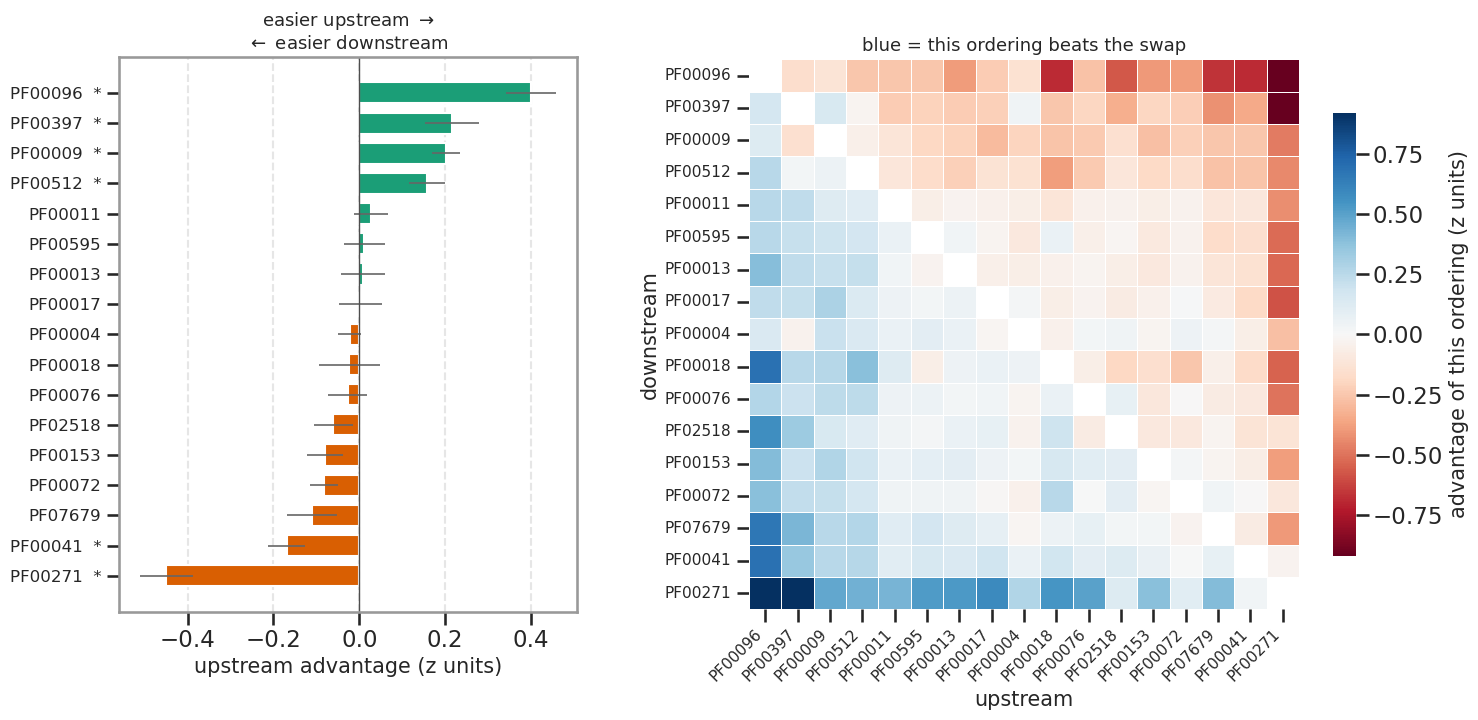

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7.2),
                         gridspec_kw={"width_ratios": [1, 1.5], "wspace": 0.3})

# (a) per-family upstream preference
ax = axes[0]
y = np.arange(len(fam))[::-1]
cols = [colorTable['g'] if v > 0 else colorTable['o'] for v in fam["mean"]]
ax.barh(y, fam["mean"], xerr=fam["sem"], color=cols, height=0.7,
        error_kw=dict(ecolor='.4', lw=1.2))
ax.set_yticks(y)
ax.set_yticklabels([f + ("  *" if q < 0.05 else "")
                    for f, q in zip(fam.index, fam.q)], fontsize=12)
ax.axvline(0, color='.3', lw=1)
ax.set_xlabel("upstream advantage (z units)")
ax.set_title("easier upstream $\\rightarrow$\n$\\leftarrow$ easier downstream", fontsize=13)
ax.grid(axis="y", visible=False)

# (b) the full ordered-pair matrix, x = upstream and y = downstream as in section 2
adv = pd.DataFrame(np.nan, index=fam.index, columns=fam.index)
for a, b, v in zip(asym.lo, asym.hi, asym.mean_dz):
    adv.loc[b, a] = -v      # (downstream=b, upstream=a): + means a-upstream wins
    adv.loc[a, b] = v
vmax = np.nanmax(np.abs(adv.values))
ax = axes[1]
sns.heatmap(adv, ax=ax, cmap=palettable.colorbrewer.diverging.RdBu_11.mpl_colormap,
            vmin=-vmax, vmax=vmax, center=0, square=True, linewidths=0.5,
            cbar_kws=dict(label="advantage of this ordering (z units)", shrink=0.8))
ax.grid(False)
ax.set_xlabel("upstream")
ax.set_ylabel("downstream")
ax.set_title("blue = this ordering beats the swap", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=11)

plt.savefig("Panels/20260820_same_strand_orientation_asymmetry.svg", bbox_inches="tight")

**The strongest pairs.** Top 20 by effect size among those at q < 0.05, each
labelled with its winning order. Bars are 95% CI on the mean.

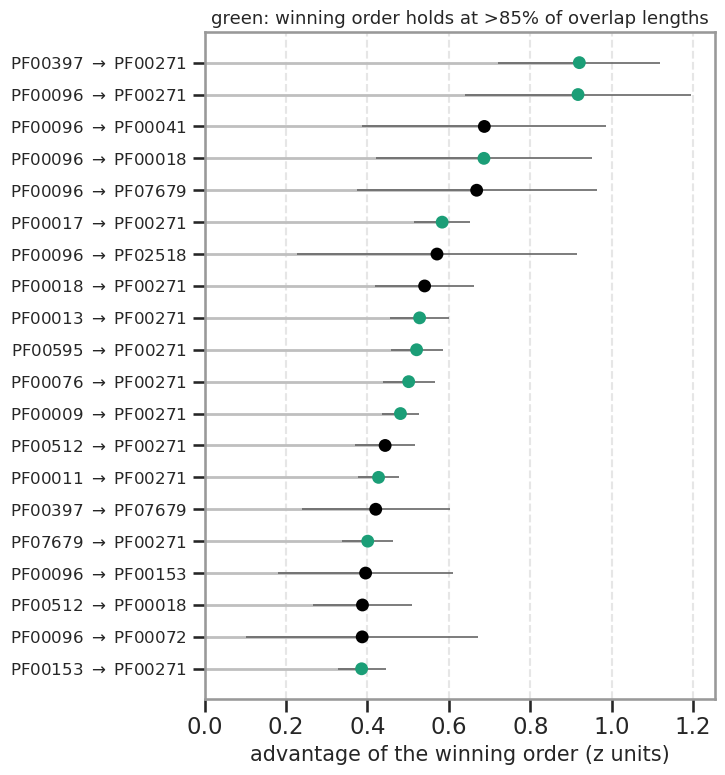

In [16]:
# The pairs with the strongest directional preference, largest first.
top = sig.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.5, 8))
y = np.arange(len(top))
ax.hlines(y, 0, top.effect, color='.75', lw=2, zorder=1)
ax.scatter(top.effect, y, s=60, zorder=3,
           c=[colorTable['g'] if c > 0.85 else colorTable['k'] for c in top.consistency])
ax.errorbar(top.effect, y, xerr=1.96 * top.sem_dz, fmt="none", ecolor='.4', lw=1.2, zorder=2)
ax.set_yticks(y)
ax.set_yticklabels([f"{u} $\\rightarrow$ {v}"
                    for u, v in zip(top.upstream_gene, top.downstream_gene)], fontsize=12)
ax.set_xlabel("advantage of the winning order (z units)")
ax.set_xlim(0, None)
ax.set_title("green: winning order holds at >85% of overlap lengths", fontsize=13)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("Panels/20260820_same_strand_orientation_top_pairs.svg", bbox_inches="tight")

**Systematic across the overlap grid.** The four most significant pairs, with the
advantage of the winning order plotted against overlap length for both frames.
The advantage sits above zero across the whole range rather than coming from one
region of overlap lengths, and both frames agree. All four are pairs with
PF00271 downstream, which is what 3.2 predicts.

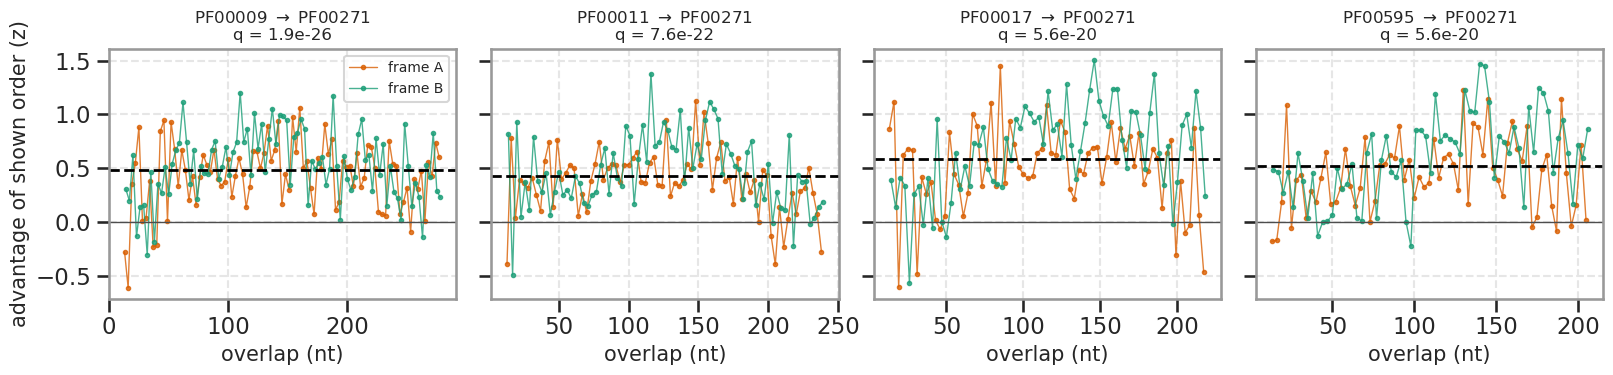

In [17]:
# "Systematic" means it holds across the overlap grid, not at one length.  Take
# the four most significant pairs -- these are the well-sampled ones, where the
# grid runs to a few hundred nt rather than the ~17 overlaps a 23 aa gene allows.
show = sig.nsmallest(4, "q")
fig, axes = plt.subplots(1, len(show), figsize=(4.1 * len(show), 4.0), sharey=True)

for ax, (_, row) in zip(np.atleast_1d(axes), show.iterrows()):
    g = paired[(paired.lo == row.lo) & (paired.hi == row.hi)].sort_values("overlap_nuc")
    # plot with the winning order on top: positive = winning order is easier
    sgn = -1 if row.mean_dz < 0 else 1
    for frame, colour in (("A", 'o'), ("B", 'g')):
        s = g[g.frame == frame]
        ax.plot(s.overlap_nuc, sgn * s.dz, "o-", ms=3, lw=1,
                color=colorTable[colour], alpha=0.8, label=f"frame {frame}")
    ax.axhline(0, color='.3', lw=1)
    ax.axhline(sgn * row.mean_dz, color=colorTable['k'], lw=2, ls="--")
    ax.set_title(f"{row.upstream_gene} $\\rightarrow$ {row.downstream_gene}\n"
                 f"q = {row.q:.1e}", fontsize=12)
    ax.set_xlabel("overlap (nt)")

np.atleast_1d(axes)[0].set_ylabel("advantage of shown order (z)")
np.atleast_1d(axes)[0].legend(fontsize=10, frameon=True)
plt.tight_layout()
plt.savefig("Panels/20260820_same_strand_orientation_vs_overlap.svg", bbox_inches="tight")

## 4. Ordering, shielding, frame — the full 2×2

Section 3 pooled the frames, and that hides two of the three things the scan
measures. Each unordered pair {X, Y} has **four** runs at every overlap length:
two orderings × two frames. They do not decompose into "ordering", "frame" and
their interaction, because ordering and frame jointly fix the codon pairing —
`(X upstream, +2)` has the *same* pairing as `(Y upstream, +1)`. Writing the four
cells as

| | frame +2 (A) | frame +1 (B) |
|---|---|---|
| **X upstream** | `a` | `b` |
| **Y upstream** | `c` | `d` |

the three contrasts that mean something physically are

| | | measures |
|---|---|---|
| **T** | ½[(a+b) − (c+d)] | **ordering** — whose C-terminus is in the overlap. Pairing cancels, so this is exactly section 3's mean `dz`. |
| **P** | ½[(a+d) − (b+c)] | **shielding** — whose 2nd codon position is protected, pooled over ordering. |
| **I** | ½[(a+c) − (b+d)] | **frame** — better to shield the C-terminal gene or the N-terminal one. This is the direct C-term vs N-term question. |

So section 3 was not measuring the wrong thing — pooling frames is the correct
estimator for T — but it left T's *interpretation* untested. That is what this
section is for.

### 4.1 The geometry, from the scan module

Which codon position of each gene the frame exposes. The wobble is free, so a
gene whose 2nd position sits opposite the partner's wobble is **shielded** at the
position that matters most; the other gene is squeezed there instead.

In [18]:
# The geometry, straight from the scan module rather than by hand.
# codon_pairing returns {upstream position: downstream position}, 0-indexed,
# so 2 is the wobble.  Frame names: the notebook's A is scan frame 1 (overlap
# %3 == 1, downstream reads +2 relative to upstream); B is scan frame 2 (+1).
POS = {0: "1st", 1: "2nd", 2: "wobble"}
FRAME_OF = {"A": 1, "B": 2}
for name in ("A", "B"):
    cp = SCAN.codon_pairing("same", FRAME_OF[name])
    shielded = ["upstream" if cp[1] == 2 else "", "downstream" if cp.get(0) == 1 else ""]
    print(f"frame {name}  (+{3 - FRAME_OF[name]}):  " +
          ",  ".join(f"up {POS[u]} : dn {POS[d]}" for u, d in cp.items()))
    print(f"           2nd position shielded by the partner's wobble: "
          f"{'upstream' if cp[1] == 2 else 'downstream'} gene\n")

frame A  (+2):  up 1st : dn 2nd,  up 2nd : dn wobble,  up wobble : dn 1st
           2nd position shielded by the partner's wobble: upstream gene

frame B  (+1):  up 1st : dn wobble,  up 2nd : dn 1st,  up wobble : dn 2nd
           2nd position shielded by the partner's wobble: downstream gene



### 4.2 The three contrasts

T and P are differences at matched overlap length and need no correction. I
compares *levels* between frames, which live at different overlap lengths, so the
frame-B curve is interpolated onto the frame-A overlaps — with B at L−2 and L+4
the weights come out 2/3 and 1/3, cancelling any linear drift of z with overlap
length. The placebo runs the identical estimator on a split of frame B against
itself, where the true answer is zero.

Only I has a meaningful mean: T and P are antisymmetric under relabelling X↔Y, so
their means are zero by construction. **The global frame effect is +0.014 z
against a placebo of −0.014** — no evidence either way that C-termini are more
constrained than N-termini in general.

In [19]:
# Four cells per unordered pair {X, Y}: 2 orderings x 2 frames.  They give three
# contrasts, and because (X up, frame A) has the SAME codon pairing as
# (Y up, frame B), the contrasts are not the naive ordering/frame/interaction:
#
#   a = z(X up, A)   X's C-term in the overlap, X shielded at its 2nd position
#   b = z(X up, B)   X's C-term in the overlap, Y (downstream) shielded
#   c = z(Y up, A)   Y's C-term in the overlap, Y shielded
#   d = z(Y up, B)   Y's C-term in the overlap, X (downstream) shielded
#
#   T = ((a+b) - (c+d))/2   ORDERING: whose C-term is in the overlap.
#                           Pairing cancels, so this is section 3's mean dz.
#   P = ((a+d) - (b+c))/2   SHIELDING: whose 2nd position is protected, pooled
#                           over ordering -> which gene is more constrained overall.
#   I = ((a+c) - (b+d))/2   FRAME: shield the C-term gene (A) or the N-term gene
#                           (B) -- the direct C-terminus vs N-terminus question.
#
# T and P are differences at matched overlap length, so they need no correction.
# I compares LEVELS across frames, which sit at different overlap lengths, so the
# frame-B curve is linearly interpolated onto the frame-A overlaps.  With A at
# L and B at L-2, L+4 the interpolation weights are 2/3, 1/3, which cancels any
# linear drift of z with overlap length exactly.
zt = df.set_index(["upstream", "downstream", "overlap_nuc"]).zscore_dist
fams = sorted(LENGTHS)

def frame_contrast(L, s):
    """(mean over frame A) - (mean over frame B) of s, matched on overlap."""
    A = L % 3 == 1
    LA, LB, sA, sB = L[A], L[~A], s[A], s[~A]
    k = (LA > LB.min()) & (LA < LB.max())
    return sA[k] - np.interp(LA[k], LB, sB)

rows, placebo = [], []
for i, X in enumerate(fams):
    for Y in fams[i + 1:]:
        zx, zy = zt.loc[(X, Y)].sort_index(), zt.loc[(Y, X)].sort_index()
        L = zx.index.values
        dz, s = zx.values - zy.values, zx.values + zy.values
        A = L % 3 == 1
        dzA, dzB = dz[A].mean(), dz[~A].mean()
        fc = frame_contrast(L, s)
        rows.append(dict(X=X, Y=Y, n=len(L), T=0.5 * (dzA + dzB), P=0.5 * (dzA - dzB),
                         I=0.5 * fc.mean(), I_sem=0.5 * stats.sem(fc), nI=len(fc)))
        # placebo: split frame B's own points into two interleaved halves and run
        # the identical estimator.  There is no frame difference there, so
        # whatever comes out is the estimator's own bias.
        Lb, sb = L[~A], s[~A]
        h1, h2, s1, s2 = Lb[::2], Lb[1::2], sb[::2], sb[1::2]
        k = (h1 > h2.min()) & (h1 < h2.max())
        if k.sum() > 3:
            placebo.append(0.5 * (s1[k] - np.interp(h1[k], h2, s2)).mean())

con = pd.DataFrame(rows)
print("contrast                                    mean      sd    t vs 0")
for k, lbl in (("T", "T  ordering (antisymmetric, mean is meaningless)"),
               ("P", "P  shielding (antisymmetric, likewise)"),
               ("I", "I  frame: shield C-term gene vs N-term gene")):
    t, p = stats.ttest_1samp(con[k], 0)
    print(f"{lbl:<44}{con[k].mean():+.3f}   {con[k].std():.3f}   t={t:+.2f} p={p:.2f}")
t, p = stats.ttest_1samp(placebo, 0)
print(f"{'placebo (same estimator, no real frame split)':<44}{np.mean(placebo):+.3f}"
      f"          t={t:+.2f} p={p:.2f}")
print(f"\nvar(T)/var(P) = {con['T'].var() / con['P'].var():.1f}, which is the "
      f"corr(dz_A, dz_B) = +0.54 of section 3.3 restated: "
      f"(1+r)/(1-r) = {(1 + 0.54) / (1 - 0.54):.1f}")

contrast                                    mean      sd    t vs 0
T  ordering (antisymmetric, mean is meaningless)-0.027   0.260   t=-1.22 p=0.22
P  shielding (antisymmetric, likewise)      +0.008   0.117   t=+0.80 p=0.42
I  frame: shield C-term gene vs N-term gene +0.015   0.096   t=+1.82 p=0.07
placebo (same estimator, no real frame split)+0.016          t=+3.05 p=0.00

var(T)/var(P) = 4.9, which is the corr(dz_A, dz_B) = +0.54 of section 3.3 restated: (1+r)/(1-r) = 3.3


### 4.3 Per-family scores

All three contrasts are close to additive in the two families, so each family gets
a score. `u` is section 3's ordering score (positive = easier upstream), `w` is
the frame score, bootstrapped over pairs. A constant bias in I would shift every
`w` equally and drop out of the centred scores, so `w` is more trustworthy than
the global mean above.

In [20]:
# Per-family scores.  T and P are antisymmetric in the pair so they fit as
# differences; I is symmetric so it fits as a sum.
idx = {f: i for i, f in enumerate(fams)}

def fit(col, symmetric):
    A = np.zeros((len(con), len(fams)))
    for r, (x, y) in enumerate(zip(con.X, con.Y)):
        A[r, idx[x]] += 1
        A[r, idx[y]] += 1 if symmetric else -1
    if symmetric:
        A = np.hstack([A, np.ones((len(con), 1))])
    v = np.linalg.lstsq(A, con[col].values, rcond=None)[0]
    R2 = 1 - ((con[col] - A @ v) ** 2).sum() / con[col].var(ddof=0) / len(con)
    v = v[:len(fams)]
    return pd.Series(v - v.mean(), index=fams), R2

# sign convention: u > 0 means the family is EASIER UPSTREAM, matching section 3
u_fit, R2_T = fit("T", symmetric=False)
u_fit = -u_fit
kappa, R2_P = fit("P", symmetric=False)
w, R2_I = fit("I", symmetric=True)

# bootstrap the frame score over pairs, to see which families it resolves at all
rng = np.random.default_rng(0)
boot = []
for _ in range(400):
    keep = rng.integers(0, len(con), len(con))
    A = np.zeros((len(con), len(fams)))
    for r, (x, y) in enumerate(zip(con.X.values[keep], con.Y.values[keep])):
        A[r, idx[x]] += 1; A[r, idx[y]] += 1
    A = np.hstack([A, np.ones((len(con), 1))])
    v = np.linalg.lstsq(A, con["I"].values[keep], rcond=None)[0][:len(fams)]
    boot.append(v - v.mean())
w_sem = pd.Series(np.std(boot, axis=0), index=fams)

score = pd.DataFrame({"u_upstream_easier": u_fit, "w_frame": w, "w_sem": w_sem,
                      "len_aa": [LENGTHS[f] for f in fams]}).sort_values(
                          "u_upstream_easier", ascending=False)
print(f"additive fits:  T R2={R2_T:.2f}   P R2={R2_P:.2f}   I R2={R2_I:.2f}\n")
print(score.round(3).to_string())
print(f"\nfamilies whose frame score clears 2 sem: "
      f"{list(score.index[(score.w_frame.abs() > 2 * score.w_sem)])}")

additive fits:  T R2=0.87   P R2=0.71   I R2=0.75

         u_upstream_easier  w_frame  w_sem  len_aa
PF00096              0.376    0.130  0.022      23
PF00397              0.204    0.147  0.019      28
PF00009              0.190   -0.075  0.018     162
PF00512              0.148    0.019  0.009      62
PF00011              0.025   -0.022  0.007      82
PF00595              0.011   -0.099  0.010      71
PF00013              0.007   -0.040  0.010      58
PF00017              0.002   -0.037  0.014      75
PF00004             -0.021   -0.046  0.007     110
PF00018             -0.022   -0.008  0.014      43
PF00076             -0.026   -0.013  0.010      59
PF02518             -0.057    0.011  0.012     101
PF00153             -0.075   -0.014  0.011      85
PF00072             -0.078    0.016  0.013     108
PF07679             -0.103    0.015  0.013      76
PF00041             -0.159    0.029  0.016      74
PF00271             -0.423   -0.013  0.010      95

families whose frame score cle

### 4.4 The test

If the ordering effect is a C-terminus/N-terminus constraint difference, the
following has to hold. Let exposure at the 2nd codon position cost `s2` and at
the 1st cost `s1`, and let each family have a constraint `c` on its C-terminal
window and `n` on its N-terminal one. Then

```
T = (s1+s2)/2 · [(c−n)_X − (c−n)_Y]      so  u ∝ −(c−n)
P = (s1−s2)/2 · [(c+n)_X − (c+n)_Y]
I = (s1−s2)/2 · [(c−n)_X + (c−n)_Y]      so  w ∝ +u
```

The last line is a genuine prediction: the frame score never saw the ordering fit,
and it should track it with a **positive** sign, and via the *sum* of the two
families' scores rather than the difference.

**It fails.** The correlation is +0.47 over all 17 families, but −0.48 over the 15
with more than 30 residues — and the two that flip it, PF00096 (23 aa) and
PF00397 (28 aa), are precisely the ones where the prediction has no content: their
grid runs to `3L−6` nt, the entire gene, so the same residues are in the overlap
whichever way round they go.

In [21]:
# The model: exposure at the 2nd codon position costs s2, at the 1st costs s1,
# and each family has a constraint c on its C-terminal window and n on its
# N-terminal one.  Then
#     T = (s1+s2)/2 * [(c-n)_X - (c-n)_Y]        so  u  ∝ -(c-n)
#     P = (s1-s2)/2 * [(c+n)_X - (c+n)_Y]
#     I = (s1-s2)/2 * [(c-n)_X + (c-n)_Y]        so  w  ∝ +u
# The last line is a real prediction: the frame score, which never saw the
# ordering fit, should track the ordering score with a POSITIVE sign.
con["usum"] = [u_fit[a] + u_fit[b] for a, b in zip(con.X, con.Y)]
short = [f for f in fams if LENGTHS[f] < 30]

for lbl, sel in (("all 17 families", fams), (f"dropping {', '.join(short)}",
                                             [f for f in fams if f not in short])):
    m = con.X.isin(sel) & con.Y.isin(sel)
    rp, pp = stats.pearsonr(con.I[m], con.usum[m])
    rf, pf = stats.pearsonr(u_fit[sel], w[sel])
    print(f"{lbl:<28} pair level r={rp:+.2f} (p={pp:.1e}, n={m.sum():3d})   "
          f"family level r={rf:+.2f} (p={pf:.2f}, n={len(sel)})")

print(f"\nThe frame score is not noise -- it is resolved for {(w.abs() > 2*w_sem).sum()} of 17 "
      f"families -- but it is dominated by the two under 30 aa\n({w[short[0]]:+.2f} and "
      f"{w[short[1]]:+.2f}, against {w[[f for f in fams if f not in short]].abs().max():.2f} "
      f"for every other family). Those two are exactly the families for which the\n"
      f"prediction is meaningless: their grid tops out at 3L-6 nt, the whole gene, so "
      f"'C-terminal window' and 'N-terminal window' are the same residues either way round.\n"
      f"Among the 15 families where the distinction is real the correlation is NEGATIVE,\n"
      f"the opposite of what the terminus model requires.")

all 17 families              pair level r=+0.33 (p=8.4e-05, n=136)   family level r=+0.38 (p=0.13, n=17)
dropping PF00096, PF00397    pair level r=-0.32 (p=7.8e-04, n=105)   family level r=-0.35 (p=0.21, n=15)

The frame score is not noise -- it is resolved for 9 of 17 families -- but it is dominated by the two under 30 aa
(+0.13 and +0.15, against 0.10 for every other family). Those two are exactly the families for which the
prediction is meaningless: their grid tops out at 3L-6 nt, the whole gene, so 'C-terminal window' and 'N-terminal window' are the same residues either way round.
Among the 15 families where the distinction is real the correlation is NEGATIVE,
the opposite of what the terminus model requires.


### 4.5 The specific prediction

PF00271 prefers downstream by 0.44 z. If that is a constrained C-terminus, then
putting it upstream should hurt more in frame **+1**, where the upstream gene's
2nd position is exposed, than in **+2**, where it is shielded.

The algebra says this does not follow. That contrast is
`penalty(+1) − penalty(+2) = (b−d) − (a−c) = −2P`, i.e. the **shielding** contrast,
which the model above ties to *total* constraint `(c+n)`, not to the terminus
difference `(c−n)`. A gene can have a badly constrained C-terminus and be
perfectly average overall, and PF00271 is exactly that.

In [22]:
# The literal prediction: PF00271 prefers downstream, so if that is a constrained
# C-terminus it should be worse upstream in frame +1 (B, where the upstream gene's
# 2nd position is exposed) than in +2 (A, where it is shielded).
# The catch: penalty_B - penalty_A = (b-d) - (a-c) = -2P, and P is the SHIELDING
# contrast, which the model above ties to total constraint (c+n), not to (c-n).
# So the prediction does not actually follow from a constrained C-terminus.
GENE = "PF00271"
sub = con[(con.X == GENE) | (con.Y == GENE)].copy()
sgn = np.where(sub.X == GENE, 1.0, -1.0)          # penalty = z(GENE up) - z(partner up)
sub["partner"] = np.where(sub.X == GENE, sub.Y, sub.X)
sub["pen_plus2"] = sgn * (sub["T"] + sub["P"])
sub["pen_plus1"] = sgn * (sub["T"] - sub["P"])
sub["diff"] = sub.pen_plus1 - sub.pen_plus2

t, p = stats.ttest_1samp(sub["diff"], 0)
print(f"{GENE} upstream penalty, averaged over its 16 partners:")
print(f"   frame +2 (2nd position shielded): {sub.pen_plus2.mean():+.3f} z")
print(f"   frame +1 (2nd position exposed):  {sub.pen_plus1.mean():+.3f} z")
print(f"   predicted to be larger in +1; observed difference "
      f"{sub['diff'].mean():+.3f} z, t={t:+.2f}, p={p:.2f}, "
      f"{(sub['diff'] > 0).sum()}/16 partners in the predicted direction")
print(f"\nThe ordering effect itself is {np.mean(sgn * sub['T']):+.2f} z and is positive "
      f"in both frames, so {GENE} really does prefer to be downstream. It simply is\n"
      f"not more constrained overall than its partners: its shielding score is "
      f"{kappa[GENE]:+.2f}, against a spread of {kappa.abs().max():.2f} across the families.")

PF00271 upstream penalty, averaged over its 16 partners:
   frame +2 (2nd position shielded): +0.430 z
   frame +1 (2nd position exposed):  +0.469 z
   predicted to be larger in +1; observed difference +0.038 z, t=+1.17, p=0.26, 10/16 partners in the predicted direction

The ordering effect itself is +0.45 z and is positive in both frames, so PF00271 really does prefer to be downstream. It simply is
not more constrained overall than its partners: its shielding score is -0.02, against a spread of 0.12 across the families.


### 4.6 Where this leaves the interpretation

**The ordering effect stands.** T is large (spread 0.28 z), robustly signed across
overlap lengths, additive in the families at R² = 0.86, and its estimator is clean.
Some genes really are easier to overlap upstream than downstream.

**Its C-term/N-term reading does not.** The contrast that tests it directly is
flat globally, and per family it runs the wrong way among every family for which
the question is well posed. Two candidate explanations that the frame contrast
would not see:

- **The stop codon.** The upstream gene's stop sits inside the overlap, so the
  *downstream* gene's N-terminal window has to absorb an in-frame stop that the
  upstream gene never has to accommodate. That is an ordering asymmetry with no
  terminus-constraint content, and it lands on the same axis as `u`.
- **Window composition rather than window constraint.** `c` and `n` in the model
  are single numbers per family; if what matters is which residues sit at the
  overlap boundary rather than how constrained the window is on average, the
  additive model is the wrong shape and I would not track u.

Separating these needs a scan variant, not a re-analysis: the same pairs with the
stop moved out of the overlap would isolate the first.

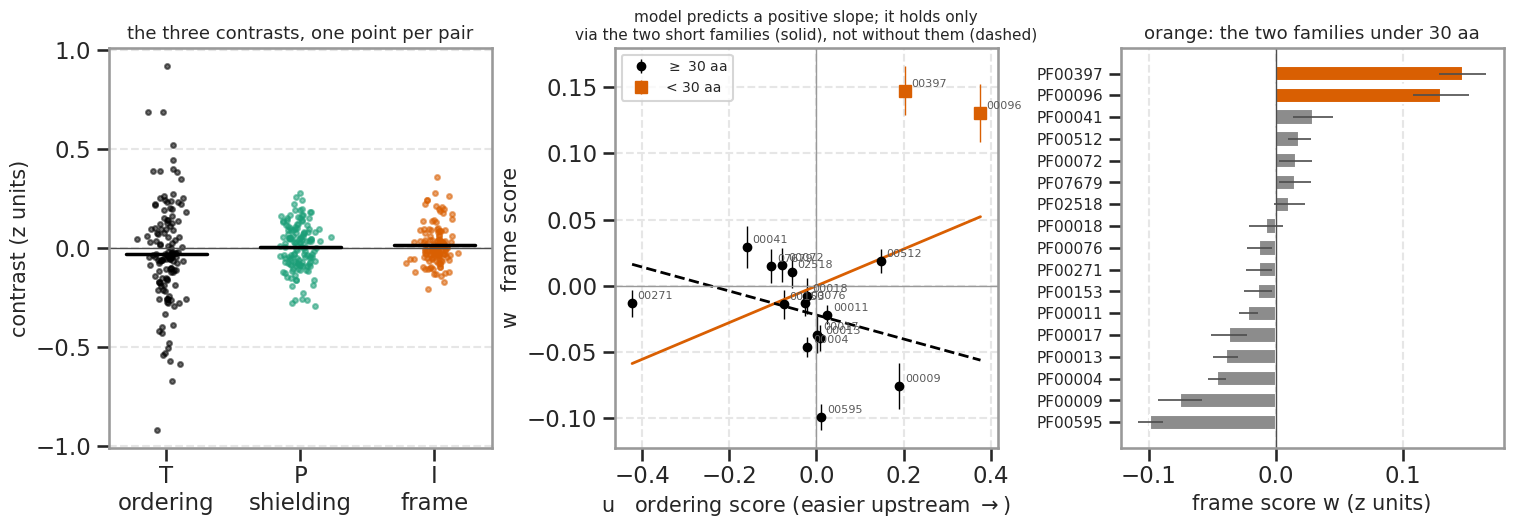

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw={"wspace": 0.32})

ax = axes[0]
for k, (lbl, col) in enumerate((("T  ordering", 'k'), ("P  shielding", 'g'),
                                ("I  frame", 'o'))):
    v = con[["T", "P", "I"]].iloc[:, k]
    ax.scatter(np.full(len(v), k) + rng.normal(0, .07, len(v)), v, s=12,
               color=colorTable[col], alpha=0.55)
    ax.plot([k - .3, k + .3], [v.mean()] * 2, color='k', lw=2.5, zorder=5)
ax.axhline(0, color='.3', lw=1)
ax.set_xticks(range(3))
ax.set_xticklabels(["T\nordering", "P\nshielding", "I\nframe"])
ax.set_ylabel("contrast (z units)")
ax.set_title("the three contrasts, one point per pair", fontsize=13)
ax.grid(axis="x", visible=False)

ax = axes[1]
ok = [f for f in fams if f not in short]
ax.errorbar(u_fit[ok], w[ok], yerr=w_sem[ok], fmt="o", color=colorTable['k'],
            ms=6, lw=1, label="$\\geq$ 30 aa")
ax.errorbar(u_fit[short], w[short], yerr=w_sem[short], fmt="s", color=colorTable['o'],
            ms=9, lw=1, label="< 30 aa")
for f in fams:
    ax.annotate(f[2:], (u_fit[f], w[f]), fontsize=8, xytext=(4, 3),
                textcoords="offset points", color='.35')
xs = np.linspace(u_fit.min(), u_fit.max(), 2)
ax.plot(xs, np.poly1d(np.polyfit(u_fit, w, 1))(xs), "-", color=colorTable['o'], lw=2)
ax.plot(xs, np.poly1d(np.polyfit(u_fit[ok], w[ok], 1))(xs), "--", color=colorTable['k'], lw=2)
ax.axhline(0, color='.6', lw=1)
ax.axvline(0, color='.6', lw=1)
ax.set_xlabel("u   ordering score (easier upstream $\\rightarrow$)")
ax.set_ylabel("w   frame score")
ax.set_title("model predicts a positive slope; it holds only\nvia the two short families (solid), not without them (dashed)",
             fontsize=11)
ax.legend(fontsize=10, loc="upper left")

ax = axes[2]
o = score.sort_values("w_frame")
y = np.arange(len(o))
ax.barh(y, o.w_frame, xerr=o.w_sem, height=.7,
        color=[colorTable['o'] if L < 30 else '.55' for L in o.len_aa],
        error_kw=dict(ecolor='.3', lw=1.2))
ax.set_yticks(y)
ax.set_yticklabels(o.index, fontsize=11)
ax.axvline(0, color='.3', lw=1)
ax.set_xlabel("frame score w (z units)")
ax.set_title("orange: the two families under 30 aa", fontsize=13)
ax.grid(axis="y", visible=False)

plt.savefig("Panels/20260820_same_strand_frame_decomposition.svg", bbox_inches="tight")

### 4.7 The answer, per family

Two questions, two columns. **(a)** Is the family easier to encode upstream or
downstream? Ten of seventeen have a preference; PF00096 (upstream) and PF00271
(downstream) are the extremes. **(b)** Is that preference stronger in +2 or in +1?
Neither frame is easier in itself, but the preference is frame-dependent for
thirteen families and its sign survives the split for only nine — and PF00271,
the strongest downstream case, shows no frame dependence at all, which is the
opposite of what a constrained C-terminus would give.

In [24]:
# The two questions, one row per family.
#   u        > 0 easier UPSTREAM (its C-terminus in the overlap), < 0 easier downstream
#   u(+2), u(+1)   the same preference measured within each frame separately.
# adv = -dz, and dz_A = T + P, dz_B = T - P, so u(+2) = u - kappa and u(+1) = u + kappa.
rng = np.random.default_rng(1)
def boot_anti(vals, B=600):
    out = []
    for _ in range(B):
        k = rng.integers(0, len(con), len(con))
        M = np.zeros((len(con), len(fams)))
        for r, (x, y) in enumerate(zip(con.X.values[k], con.Y.values[k])):
            M[r, idx[x]] += 1; M[r, idx[y]] -= 1
        out.append(np.linalg.lstsq(M, vals[k], rcond=None)[0])
    out = np.array(out)
    return (out - out.mean(1, keepdims=True)).std(0)

u2, u1 = u_fit - kappa, u_fit + kappa
sem_u = boot_anti(-con["T"].values)
sem_d = boot_anti(-2 * con["P"].values)

ans = pd.DataFrame({"len_aa": [LENGTHS[f] for f in fams], "u": u_fit, "sem_u": sem_u,
                    "u_plus2": u2, "u_plus1": u1,
                    "plus2_minus_plus1": u2 - u1, "sem_diff": sem_d})
ans["p_u"] = 2 * stats.norm.sf(np.abs(ans.u / ans.sem_u))
ans["p_diff"] = 2 * stats.norm.sf(np.abs(ans.plus2_minus_plus1 / ans.sem_diff))
ans["easier"] = np.where(ans.p_u > 0.05, "--",
                         np.where(ans.u > 0, "upstream", "downstream"))
ans = ans.sort_values("u", ascending=False)

print("(a) is the family easier upstream or downstream?\n")
print(ans[["len_aa", "u", "sem_u", "p_u", "easier"]].round(3).to_string())
print(f"\n    {(ans.p_u < 0.05).sum()} of 17 families have a preference at p < 0.05\n")
print("(b) is that preference stronger in +2 or +1?\n")
print(ans[["u_plus2", "u_plus1", "plus2_minus_plus1", "sem_diff", "p_diff"]].round(3).to_string())
print(f"\n    frame-dependent for {(ans.p_diff < 0.05).sum()} of 17 families, but the sign of "
      f"the preference itself\n    survives the split for only "
      f"{(np.sign(ans.u_plus2) == np.sign(ans.u_plus1)).sum()} of 17. The global +2 vs +1 "
      f"contrast is {2 * con['I'].mean():+.3f} z against a\n    placebo of "
      f"{2 * np.mean(placebo):+.3f}, so neither frame is easier in itself.\n")
print("    Note u(+2) - u(+1) = -2P, the SHIELDING contrast: under the section 4.4 model\n"
      "    it ranks families by TOTAL constraint, which is a different axis from the\n"
      "    C-term/N-term one that u is supposed to measure -- and the two do not agree\n"
      f"    (r = {np.corrcoef(ans.u, ans.plus2_minus_plus1)[0, 1]:+.2f} across the 17 families).")
ans.to_csv("20260820_same_strand_family_scores.csv")

(a) is the family easier upstream or downstream?

         len_aa      u  sem_u    p_u      easier
PF00096      23  0.376  0.034  0.000    upstream
PF00397      28  0.204  0.030  0.000    upstream
PF00009     162  0.190  0.019  0.000    upstream
PF00512      62  0.148  0.019  0.000    upstream
PF00011      82  0.025  0.014  0.067          --
PF00595      71  0.011  0.015  0.442          --
PF00013      58  0.007  0.011  0.503          --
PF00017      75  0.002  0.018  0.904          --
PF00004     110 -0.021  0.027  0.436          --
PF00018      43 -0.022  0.032  0.494          --
PF00076      59 -0.026  0.016  0.102          --
PF02518     101 -0.057  0.026  0.032  downstream
PF00153      85 -0.075  0.014  0.000  downstream
PF00072     108 -0.078  0.025  0.001  downstream
PF07679      76 -0.103  0.018  0.000  downstream
PF00041      74 -0.159  0.020  0.000  downstream
PF00271      95 -0.423  0.040  0.000  downstream

    10 of 17 families have a preference at p < 0.05

(b) is that pr